

## Dataset Assembly


                                       

For this project, I used a real-world dataset containing the 129 most prominent cities in Germany, provided by [SimpleMaps](https://simplemaps.com/data/de-cities). 

Germany’s federal state boundaries were loaded from [GADM (Global Administrative Areas)](https://gadm.org/download_country.html).

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import geopandas as gpd
import networkx as nx
from geopy.distance import geodesic
from shapely.geometry import LineString
import os
from IPython.display import display, HTML



In [ ]:
df = pd.read_csv('data/de.csv')
df




,city,lat,lng,country,iso2,admin_name,capital,population,population_proper
0,Berlin,52.5200,13.4050,Germany,DE,Berlin,primary,4890363.0,3755251.0
1,Stuttgart,48.7775,9.1800,Germany,DE,Baden-Württemberg,admin,2787724.0,632865.0
2,Munich,48.1375,11.5750,Germany,DE,Bavaria,admin,2606021.0,1512491.0
3,Hamburg,53.5500,10.0000,Germany,DE,Hamburg,admin,2484800.0,1892122.0
4,Cologne,50.9364,6.9528,Germany,DE,North Rhine-Westphalia,NaN,1084831.0,1084831.0
...,...,...,...,...,...,...,...,...,...
124,Altbach,48.7239,9.3797,Germany,DE,Baden-Württemberg,NaN,6422.0,6422.0
125,Merzhausen,47.9664,7.8286,Germany,DE,Baden-Württemberg,NaN,5347.0,5347.0
126,Buckenhof,49.5939,11.0500,Germany,DE,Bavaria,NaN,3157.0,3157.0
127,Offenbach,50.1006,8.7665,Germany,DE,Hesse,minor,NaN,NaN


The dataset includes 129 prominent cities in Germany. It gives information about each city's location (latitude and longitude) and population.

The geographic coordinates help us measure how close cities are to each other. This allows us to build a graph based on proximity.

The population numbers show how large each city is, so we can compare them and understand their importance in the network.

In [77]:
# # Keep only relevant columns
df = df[["city", "lat", "lng", "admin_name", "population_proper"]]

In [78]:
df.isna().sum()

city                 0
lat                  0
lng                  0
admin_name           0
population_proper    2
dtype: int64

In [79]:
# Drop rows where population_proper is missing
df = df.dropna(subset=["population_proper"])

# Rename for convenience
df = df.rename(columns={
    
    "lat": "latitude",
    "lng": "longitude",
     "admin_name": "state",
    "population_proper": "population"
})

df.head()

,city,latitude,longitude,state,population
0,Berlin,52.5200,13.4050,Berlin,3755251.0
1,Stuttgart,48.7775,9.1800,Baden-Württemberg,632865.0
2,Munich,48.1375,11.5750,Bavaria,1512491.0
3,Hamburg,53.5500,10.0000,Hamburg,1892122.0
4,Cologne,50.9364,6.9528,North Rhine-Westphalia,1084831.0


**Checking for duplicate city coordinates**

We check for duplicate city locations (same latitude and longitude). 

Since edge distances will be calculated based on geographic coordinates, cities with identical coordinates would result in zero-distance edges.
  
To avoid this issue, we remove duplicate city locations.


In [80]:
# Check for duplicate locations (same latitude & longitude)
duplicate_coords = df[df.duplicated(subset=["latitude", "longitude"], keep=False)]
print("Duplicate coordinates found:\n", duplicate_coords[["city", "latitude", "longitude"]])


Duplicate coordinates found:
         city  latitude  longitude
33   Krefeld   51.3333     6.5667
107   Bockum   51.3333     6.5667


In [81]:
df = df.drop_duplicates(subset=["latitude", "longitude"])


In [82]:
df

,city,latitude,longitude,state,population
0,Berlin,52.5200,13.4050,Berlin,3755251.0
1,Stuttgart,48.7775,9.1800,Baden-Württemberg,632865.0
2,Munich,48.1375,11.5750,Bavaria,1512491.0
3,Hamburg,53.5500,10.0000,Hamburg,1892122.0
4,Cologne,50.9364,6.9528,North Rhine-Westphalia,1084831.0
...,...,...,...,...,...
122,Neulußheim,49.2933,8.5219,Baden-Württemberg,7128.0
123,Eichwalde,52.3667,13.6167,Brandenburg,6475.0
124,Altbach,48.7239,9.3797,Baden-Württemberg,6422.0
125,Merzhausen,47.9664,7.8286,Baden-Württemberg,5347.0


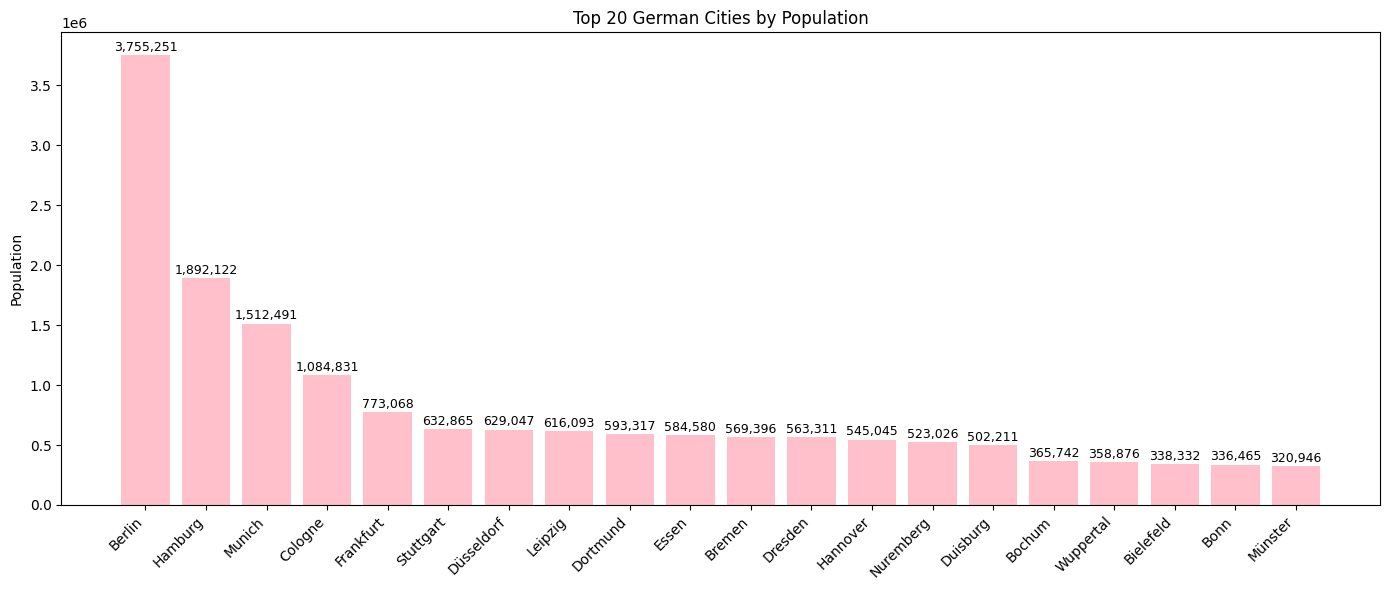

In [83]:
# Sort by population descending and take top 20
top_cities = df.sort_values("population", ascending=False).head(20)

# Plot
plt.figure(figsize=(14, 6))
bars = plt.bar(top_cities["city"], top_cities["population"], color="pink")

# Label settings
plt.ylabel("Population")
plt.title("Top 20 German Cities by Population")

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha="right")

# Add population labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 10000, f"{int(height):,}", 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


This bar chart presents the 20 most populous cities in Germany based on their population.
In the graph visualizations, cities with larger populations will be represented by larger nodes.

In [84]:
# Convert DataFrame to GeoDataFrame
geometry = [Point(xy) for xy in zip(df["longitude"], df["latitude"])]
gdf_cities = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Load state boundaries
germany_states = gpd.read_file("data/gadm41_DEU_shp/gadm41_DEU_1.shp")
germany_states = germany_states.to_crs(epsg=4326)



**Preparing Geospatial Data**

The cleaned city dataset was converted into a GeoDataFrame using each city's latitude and longitude to define its geographical location.

Germany’s federal state boundaries were loaded from [GADM (Global Administrative Areas)](https://gadm.org/download_country.html).


This spatial structure is used to visualize cities and their inter-city connections on a real map in later steps.

**Graph Construction** 

 An undirected graph will be constructed where:

- Each node represents a city.

- Edges connect cities that are geographically less than 150 km apart.

- Edge weights are calculated as 1 / distance in km, to give more importance to nearby cities.

- Node size is scaled based on the city's population.



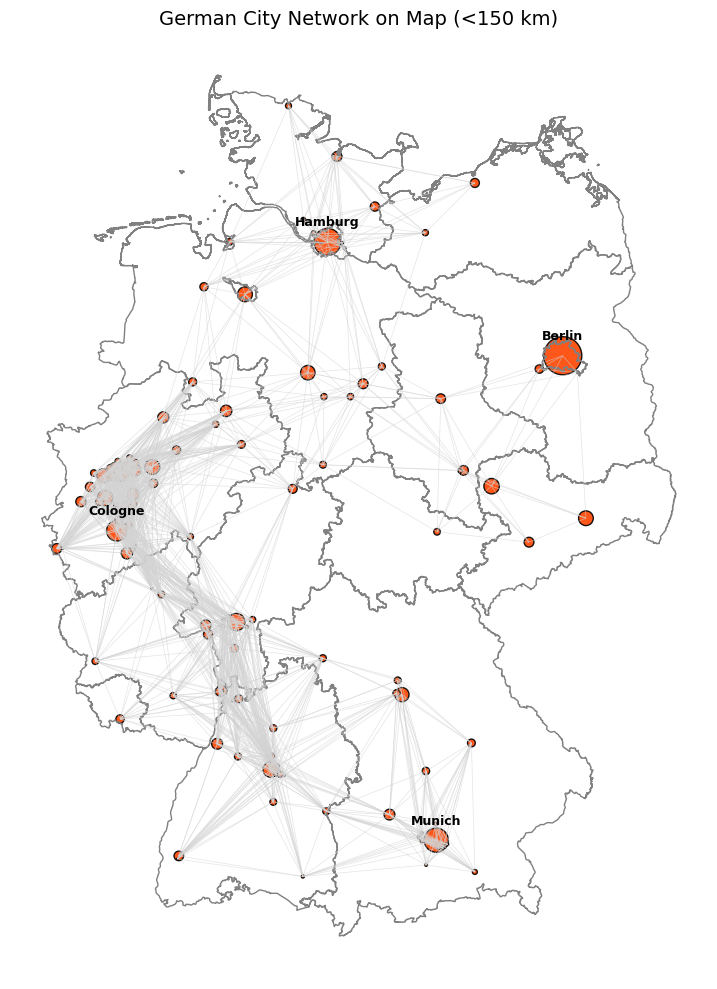

In [85]:
# Create an empty undirected graph
G = nx.Graph()

#Add nodes to the graph
for idx, row in df.iterrows():

    G.add_node(
    row["city"],
    population=row["population"],
    latitude=row["latitude"],
    longitude=row["longitude"]
)


# Add edges based on geographic distance
cities = df[["city", "latitude", "longitude"]].to_dict(orient="records")

# Loop through all pairs of cities
for i in range(len(cities)):
    for j in range(i + 1, len(cities)):
        city1 = cities[i]
        city2 = cities[j]

        loc1 = (city1["latitude"], city1["longitude"])
        loc2 = (city2["latitude"], city2["longitude"])
        distance_km = geodesic(loc1, loc2).km

        if distance_km < 150:  # only connect close cities
            G.add_edge(
                city1["city"],
                city2["city"],
                distance=distance_km,
                weight=1 / distance_km  # higher weight = closer connection
            )
            # Convert edges of G to GeoDataFrame 
edge_lines = [
    LineString([
        (G.nodes[u]["longitude"], G.nodes[u]["latitude"]),
        (G.nodes[v]["longitude"], G.nodes[v]["latitude"])
    ])
    for u, v in G.edges()
]

   
gdf_edges = gpd.GeoDataFrame(geometry=edge_lines, crs="EPSG:4326")

# Plot on geographic map
fig, ax = plt.subplots(figsize=(8, 10))

# Germany state boundaries (already loaded)
germany_states.boundary.plot(ax=ax, color="gray", linewidth=1)

# Draw edges (graph connections)
gdf_edges.plot(ax=ax, color="lightgray", linewidth=0.5, alpha=0.6)

# Draw city nodes
gdf_cities.plot(
    ax=ax,
    markersize=gdf_cities["population"] / 5000,
    color="orangered",
    edgecolor="black",
    alpha=0.9
)

# Add labels for large cities
for idx, row in gdf_cities[gdf_cities["population"] > 1_000_000].iterrows():
    ax.text(row.geometry.x, row.geometry.y + 0.15, row["city"],
            fontsize=9, ha='center', fontweight="bold", color="black")

# Visualization
plt.title("German City Network on Map (<150 km)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


In [86]:
# Create 'data' folder 

os.makedirs("data", exist_ok=True)

# Save graph as GraphML
nx.write_graphml(G, "data/germany_city_graph.graphml")
